<a href="https://colab.research.google.com/github/kinchittrivedi/Kaggle/blob/main/Advanced_NLP_Module_1_The_Attention_Revolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
google_wiki_words_tensorflow2_250_1_path = kagglehub.model_download('google/wiki-words/TensorFlow2/250/1')

print('Data source import complete.')



100%|██████████| 23.0k/23.0k [00:00<00:00, 28.0MB/s]



  0%|          | 0.00/8.27M [00:00<?, ?B/s]



  0%|          | 0.00/963M [00:00<?, ?B/s]




100%|██████████| 218/218 [00:00<00:00, 528kB/s]

 12%|█▏        | 1.00M/8.27M [00:00<00:03, 2.44MB/s]

  0%|          | 1.00M/963M [00:00<06:42, 2.50MB/s]
 36%|███▋      | 3.00M/8.27M [00:00<00:00, 6.77MB/s]

  0%|          | 3.00M/963M [00:00<02:26, 6.88MB/s]
100%|██████████| 8.27M/8.27M [00:00<00:00, 13.1MB/s]


  1%|          | 8.00M/963M [00:00<00:54, 18.3MB/s]

  1%|▏         | 13.0M/963M [00:00<00:39, 25.2MB/s]

  2%|▏         | 18.0M/963M [00:00<00:32, 30.8MB/s]

  2%|▏         | 24.0M/963M [00:01<00:26, 37.4MB/s]

  3%|▎         | 30.0M/963M [00:01<00:22, 44.1MB/s]

  4%|▎         | 35.0M/963M [00:01<00:27, 35.6MB/s]

  4%|▍         | 41.0M/963M [00:01<00:24, 39.1MB/s]

  5%|▍         | 47.0M/963M [00:01<00:21, 44.5MB/s]

  5%|▌         | 52.0M/963M [00:01<00:21, 45.3MB/s]

  6%|▌         | 57.0M/963M [00:01<00:24, 39.1MB/s]

  7%|▋         | 64.0M/963M [00:01<00:21, 43.4MB/s]

  7%|▋         | 69.0M/963M [00:02<00:21, 43.5MB/s]

  8%|▊         | 76.0M/963M [00:02<00:19, 46.

Data source import complete.


Welcome to the first module of **[Course 3: Advanced NLP — Large Language Models](kaggle.com/learn-guide/advanced-nlp)**!

In [Course 2: Intermediate NLP](https://www.kaggle.com/learn-guide/intermediate-nlp), we built LSTMs that read text one word at a time, carrying a hidden state forward through the sequence. This worked well, but it had a fundamental bottleneck: each word had to wait for the previous one before it could be understood. In this course, we replace that memory loop with **self-attention**, a mechanism that reads every word in the sequence *at the same time* and decides how much each word should "attend" to every other word. The results are transformative. Let's dive in!

# Introduction

Consider the sentence: *"The animal didn't cross the street because **it** was too tired."*

What does "it" refer to? The animal or the street? As a human, you instantly know it refers to the animal. But how? You connected a word near the end of the sentence back to a word near the beginning, based on meaning. An LSTM struggles with exactly this. Because it processes words sequentially, the gradient signal from "animal" weakens significantly by the time the model reaches "it" (the Vanishing Gradient Problem we saw in [Module 4 of Course 2](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-long-short-term-memory-lstm)).

**Self-attention solves this directly.** Instead of reading one word at a time, it looks at the *entire sequence at once* and for every word computes a score measuring how much it should pay attention to every other word. There is no waiting. There is no forgetting.

Before we had embeddings, traditional NLP used Bag-of-Words vectors that ignored word order entirely. In Course 2, LSTMs gave us order-awareness but at the cost of sequential processing. The table below shows how self-attention compares to each approach:

| Feature | Bag-of-Words / TF-IDF | LSTM (Course 2) | Self-Attention (This Course) |
|---|---|---|---|
| **Processes order?** | No | Yes, sequentially | Yes, in parallel |
| **Long-range context** | No | Limited (vanishing gradient) | Full sequence at once |
| **Training speed** | Fast | Slow (sequential) | Fast (parallelizable) |
| **Memory of full sequence** | No | Fades over distance | Complete |

This is not just faster — it is fundamentally more powerful. Let's see how it works mathematically.

# The Mathematics of Self-Attention

Self-attention works by projecting each word embedding into three different vectors using learned weight matrices. Think of these as three different "roles" every word plays simultaneously:

* **Query (Q):** "What am I looking for in the other words?"
* **Key (K):** "What information do I contain that others might want?"
* **Value (V):** "What do I actually output if someone selects me?"

For a sequence of word embeddings stacked into a matrix $X$, we compute:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

The attention output is then computed using the **Scaled Dot-Product Attention** formula:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Where:
* $QK^T$ computes a dot product score between every pair of Query and Key vectors. A high score means "this word is very relevant to that one."
* $\sqrt{d_k}$ is a scaling factor (where $d_k$ is the Key dimension) that prevents dot products from growing so large that the softmax returns vanishingly small gradients.
* The $\text{softmax}$ converts raw scores into probabilities that sum to 1.0 (deciding *how much* attention each word pays to each other word).
* Finally, these weights multiply $V$ to produce a weighted sum (a new, context-aware representation for each position).


## Why Softmax, and what are the alternatives?

The softmax function is selected here because it maps arbitrary dot-product scores into a valid probability distribution where all values are positive and sum exactly to 1.0, while remaining fully differentiable for backpropagation during training. Its exponential nature naturally accentuates the highest scores, allowing the model to focus decisively on the most relevant tokens rather than diluting attention across the entire sequence.

While softmax is the standard, several powerful alternatives exist depending on the goal:

1. **hard attention** selects a single token using a non-differentiable choice;
2. **sparsemax** allows some weights to be exactly zero for a sparser selection;
3. **sigmoid attention** calculates scores independently without sequence-wide normalization;
4. **linear attention** uses kernel functions to reduce the standard $O(N^2)$ quadratic computational complexity to linear $O(N)$ time.


Let's trace through a tiny 3-word sequence with $d_k = 4$ to make this concrete.

In [2]:
import numpy as np

def softmax(x, axis=-1):
    """Numerically stable softmax."""
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """Compute scaled dot-product attention."""
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V
    return output, weights

# Simulate a 3-word sequence with d_k = 4 dimensional Q, K, V vectors
np.random.seed(42)
d_k = 4
words = ["The", "cat", "sleeps"]

Q = np.random.randn(3, d_k)
K = np.random.randn(3, d_k)
V = np.random.randn(3, d_k)

output, attention_weights = scaled_dot_product_attention(Q, K, V)

print("Attention Weight Matrix (each row sums to 1.0):")
print(f"{'':12s} {'Key: The':>12s} {'Key: cat':>12s} {'Key: sleeps':>12s}")
for i, word in enumerate(words):
    row = " ".join([f"{w:12.4f}" for w in attention_weights[i]])
    print(f"Query: {word:<6s} {row}")

print(f"\nRow sums (should all be 1.0): {attention_weights.sum(axis=-1)}")
print(f"Output shape: {output.shape}")

Attention Weight Matrix (each row sums to 1.0):
                 Key: The     Key: cat  Key: sleeps
Query: The          0.3929       0.1682       0.4390
Query: cat          0.2309       0.2834       0.4857
Query: sleeps       0.2255       0.5587       0.2158

Row sums (should all be 1.0): [1. 1. 1.]
Output shape: (3, 4)


**Code Explanation:**
* **`softmax(x, axis=-1)`**: Converts raw attention scores into probabilities. We subtract the maximum value first (`x - np.max(x)`) to prevent numerical overflow when dot products become very large — this is the numerically stable version. `axis=-1` ensures we normalize across each row (across all Keys for each Query).
* **`scores = Q @ K.T / np.sqrt(d_k)`**: We compute dot products between every Query row and every Key row using matrix multiplication. The result is a `(seq_len × seq_len)` score matrix. We scale down by $\sqrt{d_k}$ to keep gradients healthy — without this, large dimensions cause the softmax to saturate.
* **`weights @ V`**: The final weighted sum: each row of `weights` is a probability distribution over all positions. Multiplying by `V` produces a new vector for each word, a context-aware blend of all Value vectors, weighted by relevance.
* **Reading the output matrix**: Each row is one word's attention distribution. A high value at position `[i, j]` means word `i` is paying a lot of attention to word `j`. You can see that even with random vectors, the rows sum correctly to 1.0.

The diagram below shows exactly how data flows through a single self-attention head. Notice that the input sequence feeds into **three separate linear projections simultaneously** — this is what enables parallel processing, unlike the sequential chain of an LSTM.

```mermaid
graph TD
    A["Input Sequence X<br/>(batch, seq_len, d_model)"] --> B["Linear Projection W_Q"]
    A --> C["Linear Projection W_K"]
    A --> D["Linear Projection W_V"]
    B --> E["Scaled Dot-Product<br/>Attention<br/>Q·K^T / sqrt(d_k)"]
    C --> E
    D --> F["Weighted Sum"]
    E --> G["Softmax → Attention Weights<br/>(batch, seq_len, seq_len)"]
    G --> F
    F --> H["Context-Aware Output<br/>(batch, seq_len, d_model)"]
```

Compare this to what we built in [Course 2: the LSTM](https://www.kaggle.com/code/arminnorouzig/intermediate-nlp-long-short-term-memory-lstm) had a single hidden state that had to pass from one word to the next, one step at a time. Here, **all positions are computed in a single matrix multiplication** — the key reason why Transformers train so much faster on modern hardware.

# Visualizing Attention Scores

While the numbers tell us exactly how much attention each word pays to each other, a heatmap makes the pattern immediately visible. Words with bright squares are paying high attention to each other; darker squares indicate low attention.

In a fully trained model, you would see meaningful patterns here. for example, "it" would have a bright square above "animal" in the sentence we discussed. With random vectors, the pattern is arbitrary, but the structure is identical to what a real Transformer computes.

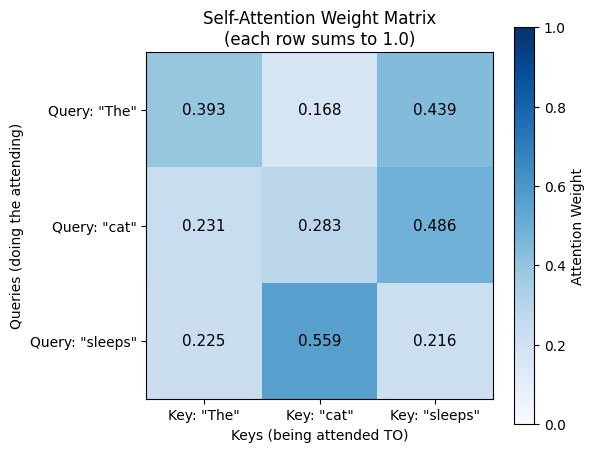


What does this tell us?
  Highest attention: 'sleeps' attends most strongly to 'cat' (0.559)


In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attention_weights, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Attention Weight')

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels([f'Key: "{w}"' for w in words])
ax.set_yticklabels([f'Query: "{w}"' for w in words])
ax.set_title("Self-Attention Weight Matrix\n(each row sums to 1.0)")
ax.set_xlabel("Keys (being attended TO)")
ax.set_ylabel("Queries (doing the attending)")

# Annotate each cell with its value
for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j, i, f"{attention_weights[i, j]:.3f}",
                ha='center', va='center', color='black', fontsize=11)

plt.tight_layout()
plt.show()

print("\nWhat does this tell us?")
max_pair = np.unravel_index(attention_weights.argmax(), attention_weights.shape)
print(f"  Highest attention: '{words[max_pair[0]]}' attends most strongly to '{words[max_pair[1]]}' ({attention_weights[max_pair]:.3f})")

**Code Explanation:**
* **`ax.imshow(attention_weights, cmap='Blues')`**: Renders the attention weight matrix as a color grid. We use the `Blues` colormap so higher weights appear darker — the same style convention used in Course 2's confusion matrix plots.
* **`vmin=0, vmax=1`**: Fixes the color scale to the full [0, 1] probability range, so colors are comparable across different weight matrices.
* **Cell annotations (`ax.text`)**: We write each weight value directly onto its cell. This makes it easy to read exact values without hovering, which is important for a static notebook rendered on Kaggle.

# Building a Small Attention Model

Now let's move from manual NumPy to a proper Keras model. TensorFlow provides a built-in `MultiHeadAttention` layer that implements the full scaled dot-product attention — across multiple parallel heads at once. We will wrap it in a simple binary sentiment classifier that takes a sequence of word embeddings and predicts Positive (1) or Negative (0).

Because we are reusing the same **Wiki-words** 250-dimensional embeddings from Course 2, our input shape is identical to what we passed into our LSTM models: `(batch_size, max_length, 250)`.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_attention_classifier(seq_len, d_model, num_heads, d_proj=None):
    """
    Binary sentiment classifier using self-attention.

    Args:
        seq_len   : maximum sequence length (number of tokens)
        d_model   : input embedding dimension (250 for Wiki-words)
        num_heads : number of parallel attention heads
        d_proj    : if set, projects embeddings to this dimension before attention
    """
    inputs = layers.Input(shape=(seq_len, d_model), name="word_embeddings")
    x = inputs

    # Optional projection: compress large embeddings to a smaller d_model
    if d_proj is not None:
        x = layers.Dense(d_proj, use_bias=False, name="input_projection")(x)
        key_dim = d_proj // num_heads
    else:
        key_dim = d_model // num_heads

    # Self-attention: every word attends to every other word simultaneously
    x = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        name="self_attention"
    )(x, x)

    # Collapse the sequence dimension — identical role to the LSTM's final hidden state
    x = layers.GlobalAveragePooling1D(name="sequence_avg")(x)

    # Binary classification output
    outputs = layers.Dense(1, activation='sigmoid', name="sentiment_output")(x)

    return Model(inputs=inputs, outputs=outputs, name="Attention_Classifier")


# Full-size model — matches the Wiki-words embedding dimension from Course 2
SEQ_LEN  = 59   # max token length from Course 2's Sentiment Dataset
D_MODEL  = 250  # Wiki-words embedding dimension
NUM_HEADS = 2

full_model = build_attention_classifier(SEQ_LEN, D_MODEL, NUM_HEADS)
print("=== Full-Size Attention Classifier ===")
full_model.summary()

=== Full-Size Attention Classifier ===


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 59, 250)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 59, 250)   │    251,000 │ word_embeddings[… │
│ (MultiHeadAttentio… │                   │            │ word_embeddings[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 250)       │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │        251 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,251 (981.45 KB)

 Trainable params: 251,251 (981.45 KB)

 Non-trainable params: 0 (0.00 B)

**Code Explanation:**
* **`layers.Input(shape=(seq_len, d_model))`**: Our input is a 3D tensor of shape `(batch_size, 59, 250)`, exactly the same shape as `X` we built throughout Course 2 after preprocessing with Wiki-words and zero-padding.
* **`d_proj` projection layer**: When we want to use a tiny `d_model` (e.g., 16) for illustration, we first project the 250-dim embeddings down. This is a standard technique; a single linear layer with no bias transforms the feature dimension without changing the sequence length.
* **`MultiHeadAttention(num_heads=2, key_dim=125)`**: This single line replaces the `layers.LSTM(...)` from Course 2. It runs 2 attention heads in parallel, each computing its own Q, K, V projections with `key_dim=125` dimensions. The results are concatenated and projected back to the original dimension.
* **`(x, x)` — self-attention**: We pass the same tensor as both `query` and `key/value`. This is the defining characteristic of *self*-attention: the sequence attends to itself. In the Decoder (Module 3), we will pass different tensors — the target sequence as query and the encoder output as key/value.
* **`GlobalAveragePooling1D()`**: After attention, we have shape `(batch, 59, 250)`. We average across all 59 positions to get a single `(batch, 250)` summary vector — conceptually identical to taking the LSTM's final hidden state, but averaging over the full sequence instead.
* **`Dense(1, activation='sigmoid')`**: Squashes the summary to a single probability between 0 (Negative) and 1 (Positive), identical to the output layer in every Course 2 model.

# Training on a Sample Dataset (Illustration Only)

Let's confirm that the attention mechanism actually trains by loading a small slice of the same **Sentiment Dataset** used throughout Course 2. We will use only **200 samples** with a **miniature model** (`d_proj=16`, `num_heads=2`) for **5 epochs**.

> **Important:** This tiny model will not achieve high accuracy and its sole purpose is to show that the attention mechanism integrates cleanly into a TensorFlow training loop and that the loss decreases. In a real deployment, you would train on the full 10,000+ sample dataset with larger dimensions, exactly as we did with our LSTM in Course 2.

In [8]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import kagglehub
import os

# 1. Load the Sentiment Dataset — same source as Course 2
dataset_path = kagglehub.dataset_download("kinchittrivedi/sentiment-analysis-movie-reviews")
positive_file = os.path.join(dataset_path, 'positive.txt')
negative_file = os.path.join(dataset_path, 'negative.txt')

with open(positive_file, "r", encoding="latin-1") as f:
    positives = [line.strip() for line in f]
with open(negative_file, "r", encoding="latin-1") as f:
    negatives = [line.strip() for line in f]

df = pd.DataFrame({
    'text':  positives + negatives,
    'label': [1] * len(positives) + [0] * len(negatives)
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Load the Wiki-words embedding model — same as Course 2
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")
embed = hub.load(model_path)

# 3. Preprocessing helpers (identical to Course 2)
def get_max_length(df):
    return max(len(row.split()) for row in df['text'])

def get_word2vec_enc(texts):
    return [embed(text.split()) for text in texts]

def get_padded_encoded_texts(encoded_texts, max_len):
    padded = []
    pad = np.zeros((1, 250))
    for enc in encoded_texts:
        n_pad = max_len - enc.shape[0]
        for _ in range(n_pad):
            enc = np.concatenate((pad, enc), axis=0)
        padded.append(enc)
    return padded

def preprocess(df, max_len):
    encoded = get_word2vec_enc(df['text'].tolist())
    padded  = get_padded_encoded_texts(encoded, max_len)
    return np.array(padded), np.array(df['label'].tolist())

# 4. Use only the first 200 samples for the tiny illustration
df_tiny = df.head(1000).reset_index(drop=True)
max_len  = get_max_length(df)   # keep same max_len as full dataset for shape consistency
print(f"Max sequence length: {max_len}")

X_tiny, Y_tiny = preprocess(df_tiny, max_len)
print(f"Tiny X shape: {X_tiny.shape}  — (samples, seq_len, embed_dim)")
print(f"Tiny Y shape: {Y_tiny.shape}")

Using Colab cache for faster access to the 'sentiment-analysis-movie-reviews' dataset.



100%|██████████| 218/218 [00:00<00:00, 62.4kB/s]



  0%|          | 0.00/963M [00:00<?, ?B/s]



100%|██████████| 23.0k/23.0k [00:00<00:00, 17.3MB/s]




  0%|          | 0.00/8.27M [00:00<?, ?B/s]
  0%|          | 1.00M/963M [00:00<06:58, 2.41MB/s]

 12%|█▏        | 1.00M/8.27M [00:00<00:03, 2.49MB/s]
  0%|          | 3.00M/963M [00:00<02:28, 6.77MB/s]
  1%|          | 8.00M/963M [00:00<00:55, 18.1MB/s]

 36%|███▋      | 3.00M/8.27M [00:00<00:00, 6.73MB/s]

 97%|█████████▋| 8.00M/8.27M [00:00<00:00, 17.8MB/s]
100%|██████████| 8.27M/8.27M [00:00<00:00, 12.9MB/s]

  2%|▏         | 20.0M/963M [00:00<00:27, 35.4MB/s]
  3%|▎         | 26.0M/963M [00:01<00:23, 42.2MB/s]
  3%|▎         | 31.0M/963M [00:01<00:22, 44.2MB/s]
  4%|▎         | 36.0M/963M [00:01<00:27, 35.4MB/s]
  4%|▍         | 42.0M/963M [00:01<00:24, 39.3MB/s]
  5%|▍         | 48.0M/963M [00:01<00:21, 44.7MB/s]
  6%|▌         | 53.0M/963M [00:01<00:24, 38.3MB/s]
  6%|▌         | 60.0M/963M [00:01<00:22, 42.2MB/s]
  7%|▋         | 66.0M/963M [00:02<00:22, 42.4MB/s]
  8%|▊         | 73.0M/963M [00:02<00:20, 45.4MB/s]
  8%|▊         | 81.0M/963M [00:02<00:18, 48.9MB/s]
  9%|▉   

Max sequence length: 101
Tiny X shape: (1000, 101, 250)  — (samples, seq_len, embed_dim)
Tiny Y shape: (1000,)


**Code Explanation:**
* **`kagglehub.dataset_download(...)`** and **`kagglehub.model_download(...)`**: These are the same two calls used in every Course 2 notebook. `kagglehub` handles caching so the download only happens once per Kaggle session.
* **`df.head(200)`**: We take only the first 200 shuffled rows. With 200 samples and 5 epochs, training completes in seconds even on CPU — the goal is to observe the mechanism, not to optimize accuracy.
* **`max_len = get_max_length(df)`**: We compute the max length over the *full* dataset, not just the 200-sample slice. This ensures our input shape is consistent with a full training run — the model architecture stays identical, only the number of rows changes.

In [9]:
# Build the tiny illustration model
# d_proj=16 compresses the 250-dim embeddings before attention — keeps training fast
tiny_model = build_attention_classifier(
    seq_len=max_len,
    d_model=250,
    num_heads=2,
    d_proj=32      # project 250 → 16 dimensions for a lightweight illustration
)

print("=== Tiny Illustration Model ===")
tiny_model.summary()

tiny_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nStarting tiny training run (200 samples, 5 epochs)...")
tiny_history = tiny_model.fit(
    X_tiny, Y_tiny,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

=== Tiny Illustration Model ===


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 101, 250)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 101, 32)   │      8,000 │ word_embeddings[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 101, 32)   │      4,224 │ input_projection… │
│ (MultiHeadAttentio… │                   │            │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 32)        │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         33 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,257 (47.88 KB)

 Trainable params: 12,257 (47.88 KB)

 Non-trainable params: 0 (0.00 B)


Starting tiny training run (200 samples, 5 epochs)...
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5138 - loss: 0.6930 - val_accuracy: 0.5050 - val_loss: 0.6914
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5975 - loss: 0.6857 - val_accuracy: 0.4900 - val_loss: 0.6865
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6075 - loss: 0.6614 - val_accuracy: 0.6000 - val_loss: 0.6594
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6438 - loss: 0.6392 - val_accuracy: 0.6300 - val_loss: 0.6440
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6600 - loss: 0.6237 - val_accuracy: 0.6250 - val_loss: 0.6743
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6587 - loss: 0.6165 - val_accuracy: 0.6600 - val_loss: 0.6201
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6587 - loss: 0.6118 - val_accuracy: 0.6450 - val_loss: 0.6230
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc

**Code Explanation:**
* **`d_proj=16`**: The 250-dimensional Wiki-words embeddings are projected down to 16 dimensions before attention. This dramatically reduces the number of parameters and computation — ideal for a quick illustration. In Module 5 we will train with full-size dimensions.
* **`num_heads=2`, `key_dim=8`**: With `d_proj=16` and 2 heads, each head operates in 8-dimensional Q/K/V space. Even this tiny configuration is enough to demonstrate that gradients flow correctly and loss decreases.
* **`validation_split=0.2`**: Holds back 40 of our 200 samples as a validation set, matching the Course 2 training pattern. With so few samples, validation accuracy will fluctuate — this is expected.
* **`batch_size=16`**: Smaller batches than Course 2's 32 because our dataset is much smaller as we need at least a few batches per epoch to see meaningful gradient updates.

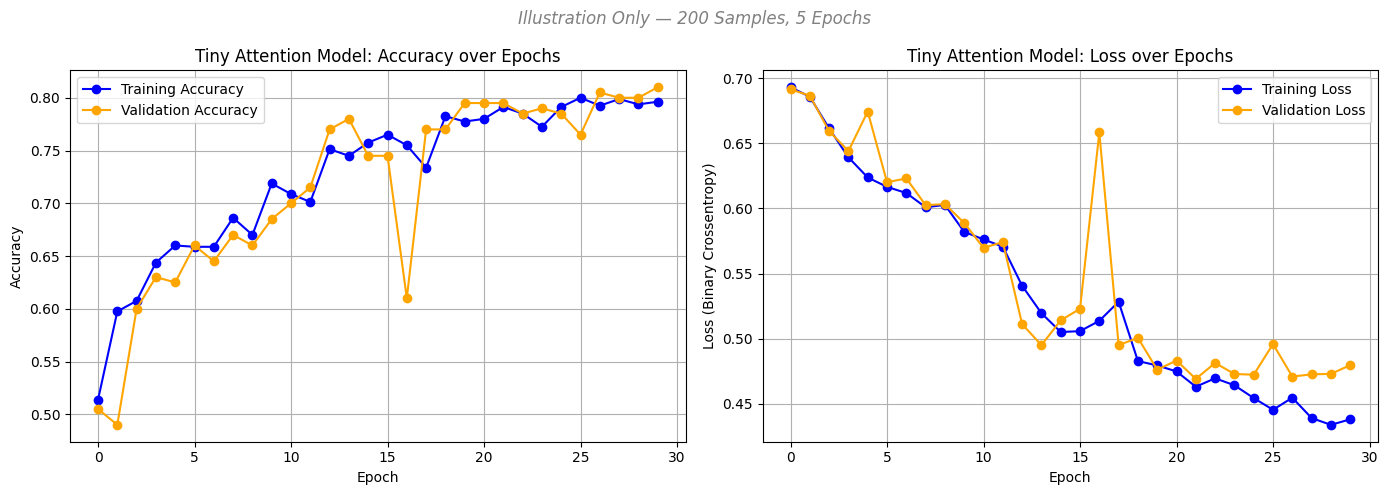


Key observation: the training loss decreased — self-attention trains successfully!
Final training loss:   0.4382
Final training accuracy: 0.7962


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(tiny_history.history['accuracy'],     label='Training Accuracy',   color='blue',   marker='o')
ax1.plot(tiny_history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='o')
ax1.set_title('Tiny Attention Model: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(tiny_history.history['loss'],     label='Training Loss',   color='blue',   marker='o')
ax2.plot(tiny_history.history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.set_title('Tiny Attention Model: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Binary Crossentropy)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Illustration Only — 200 Samples, 5 Epochs', fontstyle='italic', color='gray')
plt.tight_layout()
plt.show()

print("\nKey observation: the training loss decreased — self-attention trains successfully!")
print(f"Final training loss:   {tiny_history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {tiny_history.history['accuracy'][-1]:.4f}")

**Code Explanation:**
* **Plot style**: Blue for training, orange for validation, `marker='o'`, `grid=True`, identical to every learning curve in Course 2. Consistency makes it easy to compare across modules.
* **`plt.suptitle` italic gray label**: A clear visual reminder that these curves represent a toy illustration, not a production result. With only 200 samples, validation accuracy will be noisy — this is expected and fine.
* **What to look for**: The key signal is that the **training loss decreases** over 5 epochs. This confirms that self-attention supports standard gradient-based optimization — the backward pass works correctly through the attention weights.

# Conclusion & Next Steps

In this module, we made a fundamental shift away from sequential processing. We started from the mathematical core — computing Query, Key, and Value projections and combining them into context-aware output vectors using Scaled Dot-Product Attention. We visualized the attention weight matrix as a heatmap, built a Keras model using TensorFlow's `MultiHeadAttention` layer, and confirmed that the whole pipeline trains correctly on the Sentiment Dataset we know from Course 2.

However, self-attention has one surprising blind spot: it is **completely order-agnostic**. Shuffle the words in our sentence and the attention scores do not change — the mechanism has no concept of which word came first. Attention reads the entire sequence in parallel, which is what makes it fast, but it also means we need to explicitly tell the model about word order.

In **[Module 2: Positional Encoding](https://www.kaggle.com/code/arminnorouzig/advanced-nlp-positional-encoding)**, we will fix this by injecting a mathematical sense of position directly into the word embeddings using sine and cosine functions — no extra trainable parameters required!

<script type="module">
  import mermaid from 'https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs';

  // Find ALL generic code blocks
  const blocks = document.querySelectorAll('pre code');

  blocks.forEach((block) => {
      let text = block.textContent.trim();
      let isMermaid = false;
      let diagramCode = text;

      // Case 1: Check if the element or its parent has a mermaid class
      const hasMermaidClass = Array.from(block.classList).some(cls => cls.includes('mermaid')) ||
                             (block.parentElement && Array.from(block.parentElement.classList).some(cls => cls.includes('mermaid')));

      if (hasMermaidClass) {
          isMermaid = true;
      }
      // Case 2: Check if the text literally starts with the word "mermaid"
      else if (text.startsWith('mermaid')) {
          isMermaid = true;
          // Strip out the word "mermaid" and any leading whitespace/newlines
          diagramCode = text.replace(/^mermaid\s*/i, '');
      }

      if (isMermaid) {
          // Create a proper div for Mermaid
          const div = document.createElement('div');
          div.className = 'mermaid';
          div.textContent = diagramCode;

          // Replace the parent <pre> tag with the new div
          const pre = block.parentElement;
          if (pre && pre.tagName === 'PRE') {
              pre.replaceWith(div);
          }
      }
  });

  // Initialize and run the render
  mermaid.initialize({ startOnLoad: false });
  await mermaid.run();
</script>
